In [118]:
from fredapi import Fred
from dotenv import load_dotenv
import os
import pandas as pd
import yfinance as yf

project_root = '/Users/namansoni/Project/macro-regime-classifier'

load_dotenv()
FRED_API_KEY = os.getenv("FRED_API_KEY")
fred = Fred(api_key = FRED_API_KEY)

#Creating the dictionary holding the key series that define economic health
series_ids = {
    'cpi': 'CPIAUCSL',
    'yield_curve': 'T10Y2Y',
    'unemployment': 'UNRATE',
    'credit_spread': 'BAA10Y',
    'gdp_growth': 'A191RL1Q225SBEA',
    'consumer_sent': 'UMCSENT',
    'indust_prod': 'INDPRO',
}
print(series_ids)

{'cpi': 'CPIAUCSL', 'yield_curve': 'T10Y2Y', 'unemployment': 'UNRATE', 'credit_spread': 'BAA10Y', 'gdp_growth': 'A191RL1Q225SBEA', 'consumer_sent': 'UMCSENT', 'indust_prod': 'INDPRO'}


In [119]:
#Pulling the monthly data from FRED for each of the series in the series_ids dictionary starting from January 2001 to the most recent data
raw = {}
for name, series_id in series_ids.items():
    raw[name] = fred.get_series(series_id, observation_start = '2000-01-01')
    print(f"{name}: {len(raw[name])} observations | start: {raw[name].index[0].date()} | end: {raw[name].index[-1].date()}")

cpi: 317 observations | start: 2000-01-01 | end: 2026-05-01
yield_curve: 6919 observations | start: 2000-01-03 | end: 2026-07-09
unemployment: 318 observations | start: 2000-01-01 | end: 2026-06-01
credit_spread: 6918 observations | start: 2000-01-03 | end: 2026-07-08
gdp_growth: 105 observations | start: 2000-01-01 | end: 2026-01-01
consumer_sent: 317 observations | start: 2000-01-01 | end: 2026-05-01
indust_prod: 317 observations | start: 2000-01-01 | end: 2026-05-01


In [120]:
#Since there are different reportings of each series, the data must be manipulated such that it can be analyzed properly. We will be using a new dictionary to ensure the original data isn't damaged/touched
features = {}
# 1. CPI alone doesn't tell us much, so we need to calculate how much it has increased since the same time the year before to understand how fast prices are rising: 
features['cpi'] = raw['cpi'].pct_change(12)
# 2. Employment must be converted similarly to give a month to month change. However this time we use the .diff(n) with n = 1 method to find the difference between each row.
features['unemployment'] = raw['unemployment'].diff(1)
# 3. The GDP is only reported quarterly. But to match the rest of the data (which is monthly) to be able to use the data adequately. So we'll linearly interpolate from quarterly to monthly to fill in the missing values
# First we add NaN values for all the months between the gdp reportings using the resample method on ('ME') Month End frequency, so add a value for each month. Then the interpolate method is used to linearly fill those NaN values
features['gdp_growth'] = raw['gdp_growth'].resample('ME').first().interpolate(method = 'linear')
# 4/5. Yield Curve data and Credit spread must be resampled from having data for every day to having data for every month, so it can be used with the other series that have been resampled to monthly. 
features['yield_curve'] = raw['yield_curve'].resample('ME').last()
features['credit_spread'] = raw['credit_spread'].resample('ME').last()
# 6. Similar to Unemployment, the consumer sentiment and industrial production must be added to features as differences from the previous row.
features['consumer_sent'] = raw['consumer_sent'].diff(1)
features['indust_prod'] = raw['indust_prod'].diff(1)
#Writing a sanity check to make sure its working properly
for name, series in features.items():
    print(f"{name}: {len(features[name])} observations | start: {features[name].index[0].date()} | end: {features[name].index[-1].date()} | NaN count: {features[name].isna().sum()}")
    print(series.dropna().head(3))

cpi: 317 observations | start: 2000-01-01 | end: 2026-05-01 | NaN count: 13
2001-01-01    0.037212
2001-02-01    0.035294
2001-03-01    0.029825
dtype: float64
unemployment: 318 observations | start: 2000-01-01 | end: 2026-06-01 | NaN count: 3
2000-02-01    0.1
2000-03-01   -0.1
2000-04-01   -0.2
dtype: float64
gdp_growth: 313 observations | start: 2000-01-31 | end: 2026-01-31 | NaN count: 0
2000-01-31    1.5
2000-02-29    3.5
2000-03-31    5.5
Freq: ME, dtype: float64
yield_curve: 319 observations | start: 2000-01-31 | end: 2026-07-31 | NaN count: 0
2000-01-31    0.07
2000-02-29   -0.11
2000-03-31   -0.47
Freq: ME, dtype: float64
credit_spread: 319 observations | start: 2000-01-31 | end: 2026-07-31 | NaN count: 0
2000-01-31    1.68
2000-02-29    1.91
2000-03-31    2.30
Freq: ME, dtype: float64
consumer_sent: 317 observations | start: 2000-01-01 | end: 2026-05-01 | NaN count: 1
2000-02-01   -0.7
2000-03-01   -4.2
2000-04-01    2.1
dtype: float64
indust_prod: 317 observations | start: 2

In [121]:

# Now this raw data must be saved into the data folder for access in the future. This is so that we don't have to do a api call each time we run the file or run any method. A CSV file will be created by first converting the dictionary (features) into a dataframe.
raw_df = pd.DataFrame(features)
print(raw_df.head(3))
raw_df.to_csv(os.path.join(project_root, 'data', 'macro_features_raw.csv'))

# Important note: This csv is my features before alignment (which will be done tomorrow) 

            cpi  unemployment  gdp_growth  yield_curve  credit_spread  \
2000-01-01  NaN           NaN         NaN          NaN            NaN   
2000-01-31  NaN           NaN         1.5         0.07           1.68   
2000-02-01  NaN           0.1         NaN          NaN            NaN   

            consumer_sent  indust_prod  
2000-01-01            NaN          NaN  
2000-01-31            NaN          NaN  
2000-02-01           -0.7       0.2859  


In [122]:
# Day 3: Now we will be taking the misaligned csv file and turning it into a clean dataframe to be used and analyzed in the future. Such that each series is saved on the last day of the month
for series in features: 
    features[series] = features[series].resample('ME').last()

#Sanity Loop:
for name, series in features.items():
    print(f"{name}: {len(features[name])} observations | start: {features[name].index[0].date()} | end: {features[name].index[-1].date()} | NaN count: {features[name].isna().sum()}")
    print(series.dropna().head(3))

cpi: 317 observations | start: 2000-01-31 | end: 2026-05-31 | NaN count: 13
2001-01-31    0.037212
2001-02-28    0.035294
2001-03-31    0.029825
dtype: float64
unemployment: 318 observations | start: 2000-01-31 | end: 2026-06-30 | NaN count: 3
2000-02-29    0.1
2000-03-31   -0.1
2000-04-30   -0.2
dtype: float64
gdp_growth: 313 observations | start: 2000-01-31 | end: 2026-01-31 | NaN count: 0
2000-01-31    1.5
2000-02-29    3.5
2000-03-31    5.5
Freq: ME, dtype: float64
yield_curve: 319 observations | start: 2000-01-31 | end: 2026-07-31 | NaN count: 0
2000-01-31    0.07
2000-02-29   -0.11
2000-03-31   -0.47
Freq: ME, dtype: float64
credit_spread: 319 observations | start: 2000-01-31 | end: 2026-07-31 | NaN count: 0
2000-01-31    1.68
2000-02-29    1.91
2000-03-31    2.30
Freq: ME, dtype: float64
consumer_sent: 317 observations | start: 2000-01-31 | end: 2026-05-31 | NaN count: 1
2000-02-29   -0.7
2000-03-31   -4.2
2000-04-30    2.1
Freq: ME, dtype: float64
indust_prod: 317 observations 

In [123]:
aligned_df = pd.DataFrame(features)
print(aligned_df.head(5))
print(aligned_df.shape)

            cpi  unemployment  gdp_growth  yield_curve  credit_spread  \
2000-01-31  NaN           NaN    1.500000         0.07           1.68   
2000-02-29  NaN           0.1    3.500000        -0.11           1.91   
2000-03-31  NaN          -0.1    5.500000        -0.47           2.30   
2000-04-30  NaN          -0.2    7.500000        -0.45           2.34   
2000-05-31  NaN           0.2    5.133333        -0.40           2.52   

            consumer_sent  indust_prod  
2000-01-31            NaN          NaN  
2000-02-29           -0.7       0.2859  
2000-03-31           -4.2       0.3265  
2000-04-30            2.1       0.5485  
2000-05-31            1.5       0.2510  
(319, 7)


In [124]:
aligned_df = aligned_df.ffill().bfill()

#Technical and Visual check -> Should be all 0 NaNs from the first print. The second print (the table) should not show any NaNs and the third should be (currently (319, 7) ) saying that there have been 319 months since January 2000.
print(aligned_df.isnull().sum())
print(aligned_df.head(5))
print(aligned_df.shape)

cpi              0
unemployment     0
gdp_growth       0
yield_curve      0
credit_spread    0
consumer_sent    0
indust_prod      0
dtype: int64
                 cpi  unemployment  gdp_growth  yield_curve  credit_spread  \
2000-01-31  0.037212           0.1    1.500000         0.07           1.68   
2000-02-29  0.037212           0.1    3.500000        -0.11           1.91   
2000-03-31  0.037212          -0.1    5.500000        -0.47           2.30   
2000-04-30  0.037212          -0.2    7.500000        -0.45           2.34   
2000-05-31  0.037212           0.2    5.133333        -0.40           2.52   

            consumer_sent  indust_prod  
2000-01-31           -0.7       0.2859  
2000-02-29           -0.7       0.2859  
2000-03-31           -4.2       0.3265  
2000-04-30            2.1       0.5485  
2000-05-31            1.5       0.2510  
(319, 7)


In [125]:
aligned_df.to_csv(os.path.join(project_root, 'data', 'macro_features_clean.csv'))

In [126]:
# Now pulling the data for the 8 etfs that represent each sector of the market and SPY which represents the S&P 500 aka the overall market
tickers = ['XLK', 'XLE', 'XLF', 'XLV', 'XLI', 'XLP', 'XLU', 'XLB', 'SPY']

etf_translations = {
    'XLK': 'Technology',
    'XLE': 'Energy',
    'XLF': 'Financials',
    'XLV': 'Healthcare',
    'XLI': 'Industrials',
    'XLP': 'Consumer Staples',
    'XLU': 'Utilities',
    'XLB': 'Materials',
    'SPY': 'S&P 500 Benchmark'
}

In [135]:
etf_prices = {}
for tick in tickers:
    etf_prices[tick] = yf.download(tick, start = '2000-01-01', progress = False, auto_adjust = True)['Close']

In [139]:
# Now resample such that we are only using the last value of each month for each month.
for tick in etf_prices: 
    etf_prices[tick] = etf_prices[tick].resample('ME').last()

#Check that only last days of months are in the etf_prices dictionary, values for each month, and that there are no NaN values
for name in etf_prices:
    print(f"{name}: {len(etf_prices[name])} observations | start: {etf_prices[name].index[0].date()} | end: {etf_prices[name].index[-1].date()} | NaN count: {etf_prices[name].isna().sum()}")
    print(etf_prices[name].dropna().head(3))

XLK: 319 observations | start: 2000-01-31 | end: 2026-07-31 | NaN count: Ticker
XLK    0
dtype: int64
Ticker            XLK
Date                 
2000-01-31  18.790165
2000-02-29  20.764410
2000-03-31  22.506380
XLE: 319 observations | start: 2000-01-31 | end: 2026-07-31 | NaN count: Ticker
XLE    0
dtype: int64
Ticker           XLE
Date                
2000-01-31  6.794844
2000-02-29  6.507193
2000-03-31  7.316840
XLF: 319 observations | start: 2000-01-31 | end: 2026-07-31 | NaN count: Ticker
XLF    0
dtype: int64
Ticker            XLF
Date                 
2000-01-31  11.142778
2000-02-29   9.949989
2000-03-31  11.767097
XLV: 319 observations | start: 2000-01-31 | end: 2026-07-31 | NaN count: Ticker
XLV    0
dtype: int64
Ticker            XLV
Date                 
2000-01-31  20.225042
2000-02-29  18.902597
2000-03-31  20.602886
XLI: 319 observations | start: 2000-01-31 | end: 2026-07-31 | NaN count: Ticker
XLI    0
dtype: int64
Ticker            XLI
Date                 
2000-01-31 

In [144]:
# Compute monthly returns for each stock: (end / start) - 1.0

etf_returns = {}

for name in etf_prices: 
    etf_returns[name] = etf_prices[name].pct_change(1).squeeze()
    print(etf_returns[name].head(3))

Date
2000-01-31         NaN
2000-02-29    0.105068
2000-03-31    0.083892
Freq: ME, Name: XLK, dtype: float64
Date
2000-01-31         NaN
2000-02-29   -0.042334
2000-03-31    0.124423
Freq: ME, Name: XLE, dtype: float64
Date
2000-01-31         NaN
2000-02-29   -0.107046
2000-03-31    0.182624
Freq: ME, Name: XLF, dtype: float64
Date
2000-01-31         NaN
2000-02-29   -0.065387
2000-03-31    0.089950
Freq: ME, Name: XLV, dtype: float64
Date
2000-01-31         NaN
2000-02-29   -0.055172
2000-03-31    0.139206
Freq: ME, Name: XLI, dtype: float64
Date
2000-01-31         NaN
2000-02-29   -0.117014
2000-03-31    0.037593
Freq: ME, Name: XLP, dtype: float64
Date
2000-01-31         NaN
2000-02-29   -0.121538
2000-03-31    0.109237
Freq: ME, Name: XLU, dtype: float64
Date
2000-01-31         NaN
2000-02-29   -0.100469
2000-03-31    0.100893
Freq: ME, Name: XLB, dtype: float64
Date
2000-01-31         NaN
2000-02-29   -0.015226
2000-03-31    0.096914
Freq: ME, Name: SPY, dtype: float64


In [147]:
returns_df = pd.DataFrame(etf_returns)

#Check to see that the dataframe was made as needed
print(returns_df.head(3))
print(returns_df.size)

                 XLK       XLE       XLF       XLV       XLI       XLP  \
Date                                                                     
2000-01-31       NaN       NaN       NaN       NaN       NaN       NaN   
2000-02-29  0.105068 -0.042334 -0.107046 -0.065387 -0.055172 -0.117014   
2000-03-31  0.083892  0.124423  0.182624  0.089950  0.139206  0.037593   

                 XLU       XLB       SPY  
Date                                      
2000-01-31       NaN       NaN       NaN  
2000-02-29 -0.121538 -0.100469 -0.015226  
2000-03-31  0.109237  0.100893  0.096914  
2871


In [148]:
# Convert to a csv:
returns_df.to_csv(os.path.join(project_root, 'data', 'sector_returns.csv'))

In [ ]:
# Day 4 -> Pulling USREC from FRED to create visuals that help us determine when a recession was and compare it with the series at those times. 
recession = fred.get_series('USREC', observation_start = '2000-01-01').resample('ME').last()
#Sanity check to make sure the recession data is accurate for 2001
print(recession['2001-01-31':'2001-12-31'])

2001-01-31    0.0
2001-02-28    0.0
2001-03-31    0.0
2001-04-30    1.0
2001-05-31    1.0
2001-06-30    1.0
2001-07-31    1.0
2001-08-31    1.0
2001-09-30    1.0
2001-10-31    1.0
2001-11-30    1.0
2001-12-31    0.0
Freq: ME, dtype: float64


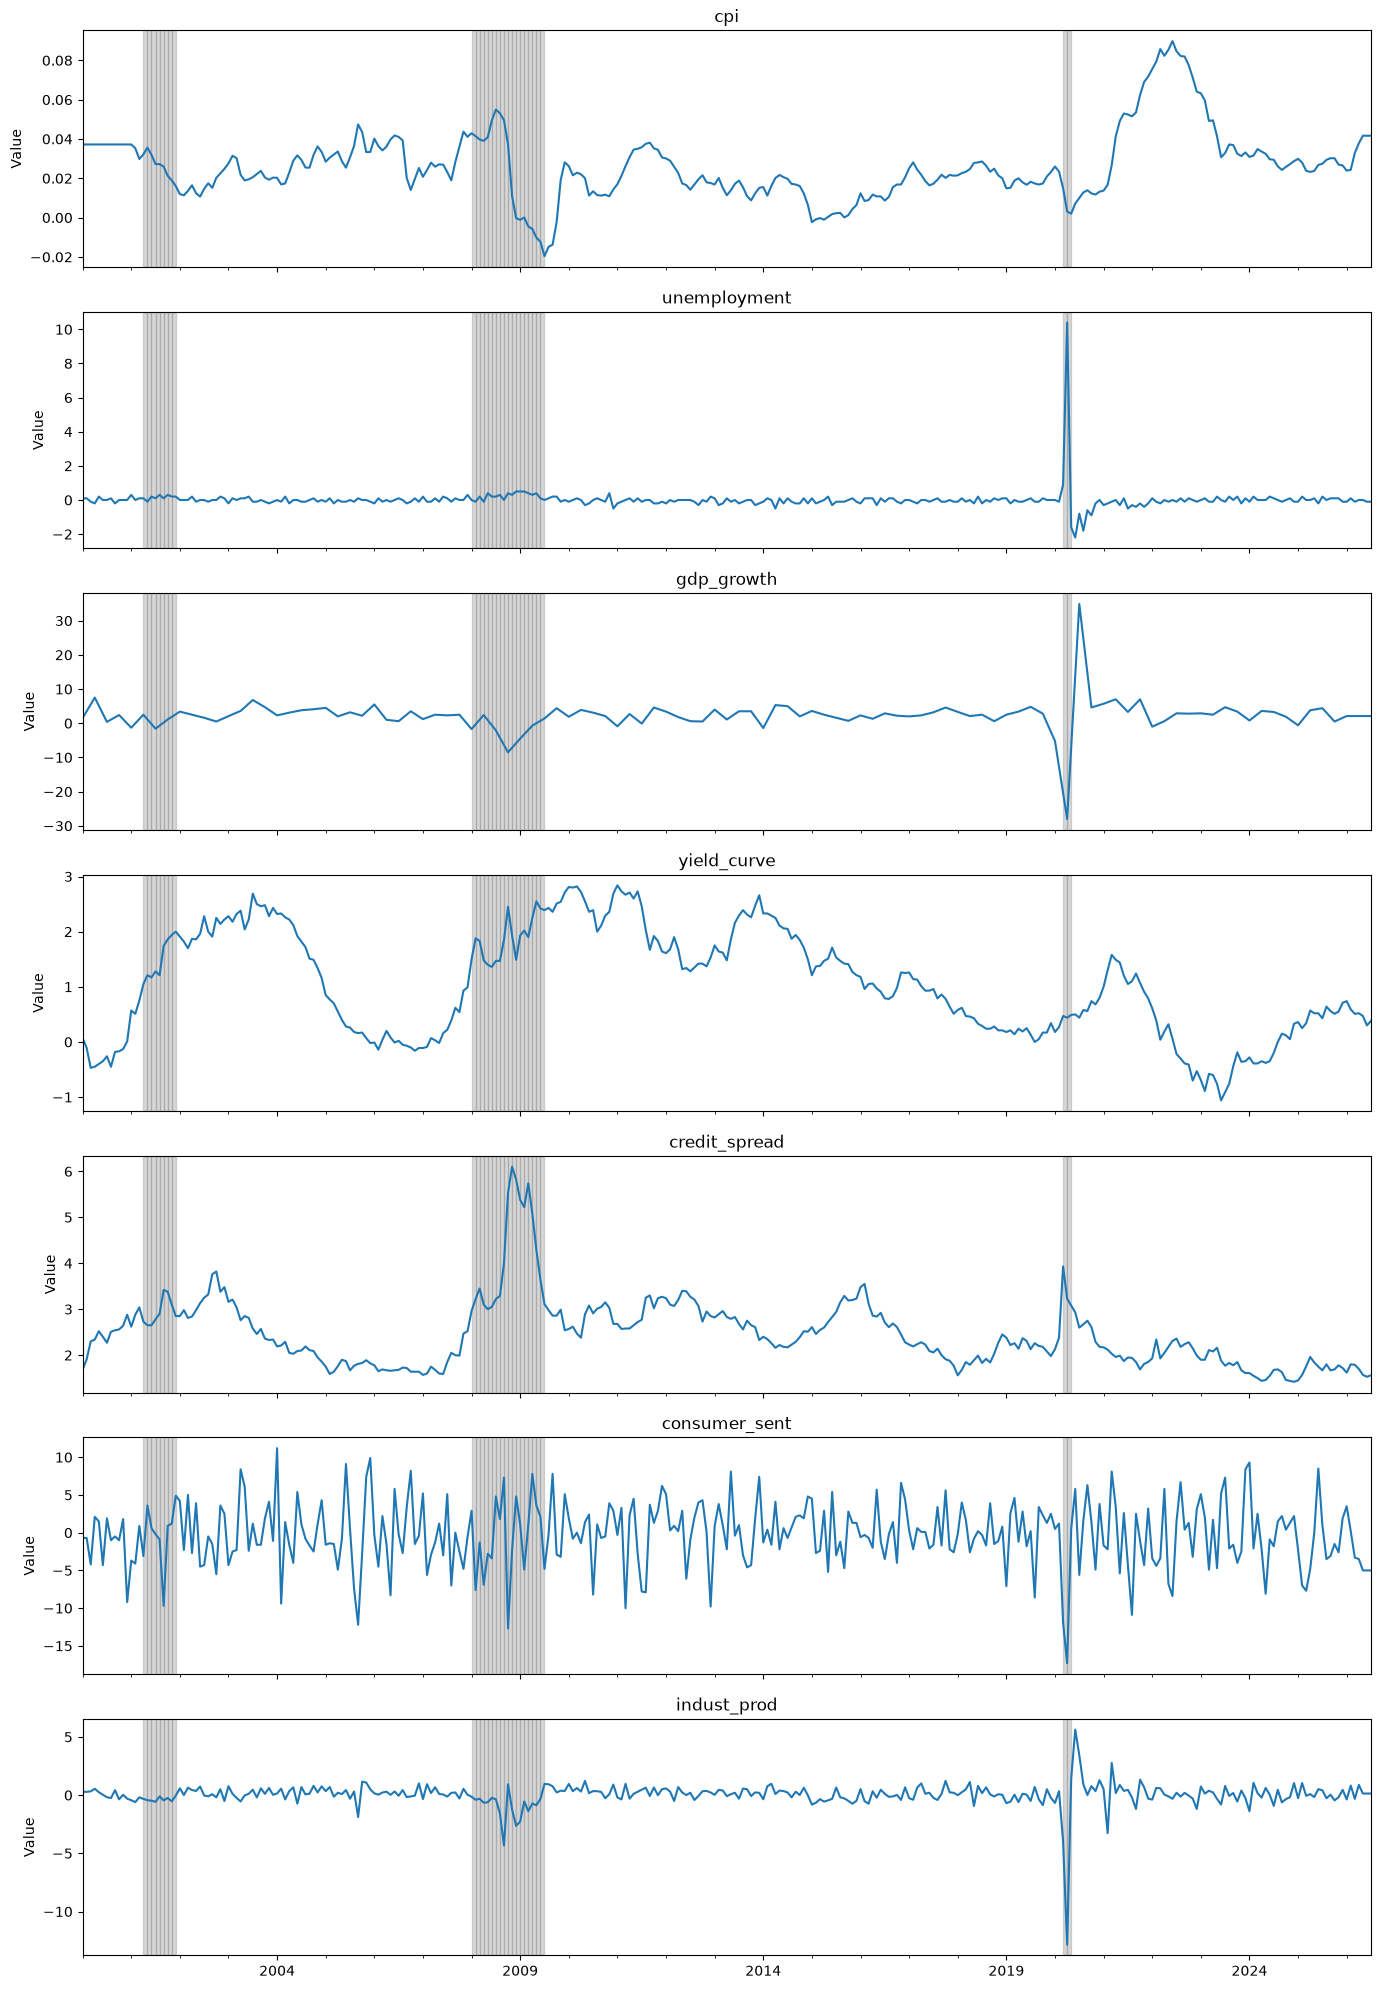

In [169]:
import matplotlib.pyplot as plt
# Now we start plotting with MatPlotLib:
# 1. First plot is a time series of each macro-feature with recession periods shaded in. 

fig, axes = plt.subplots(7, 1, figsize = (14, 20), sharex = True)

for i, col in enumerate(aligned_df.columns):
    ax = axes[i]
    aligned_df[col].plot(ax = ax)
    ax.set_title(col)
    ax.set_ylabel("Value")
    for date, value in recession.items():
        if value == 1:
            ax.axvspan(date, date + pd.offsets.MonthEnd(1), color = 'grey', alpha = 0.3)
        
plt.tight_layout()
plt.savefig(os.path.join(project_root, 'outputs', 'macro_features_eda.png'))
plt.show()

                    cpi  unemployment  gdp_growth  yield_curve  credit_spread  \
cpi            1.000000     -0.061959    0.006464    -0.430306      -0.377183   
unemployment  -0.061959      1.000000   -0.574798    -0.015031       0.128292   
gdp_growth     0.006464     -0.574798    1.000000    -0.039505      -0.304862   
yield_curve   -0.430306     -0.015031   -0.039505     1.000000       0.548690   
credit_spread -0.377183      0.128292   -0.304862     0.548690       1.000000   
consumer_sent -0.104062     -0.252760    0.177604     0.045239      -0.021067   
indust_prod    0.042664     -0.762359    0.612320     0.030749      -0.228298   

               consumer_sent  indust_prod  
cpi                -0.104062     0.042664  
unemployment       -0.252760    -0.762359  
gdp_growth          0.177604     0.612320  
yield_curve         0.045239     0.030749  
credit_spread      -0.021067    -0.228298  
consumer_sent       1.000000     0.159004  
indust_prod         0.159004     1.000000  

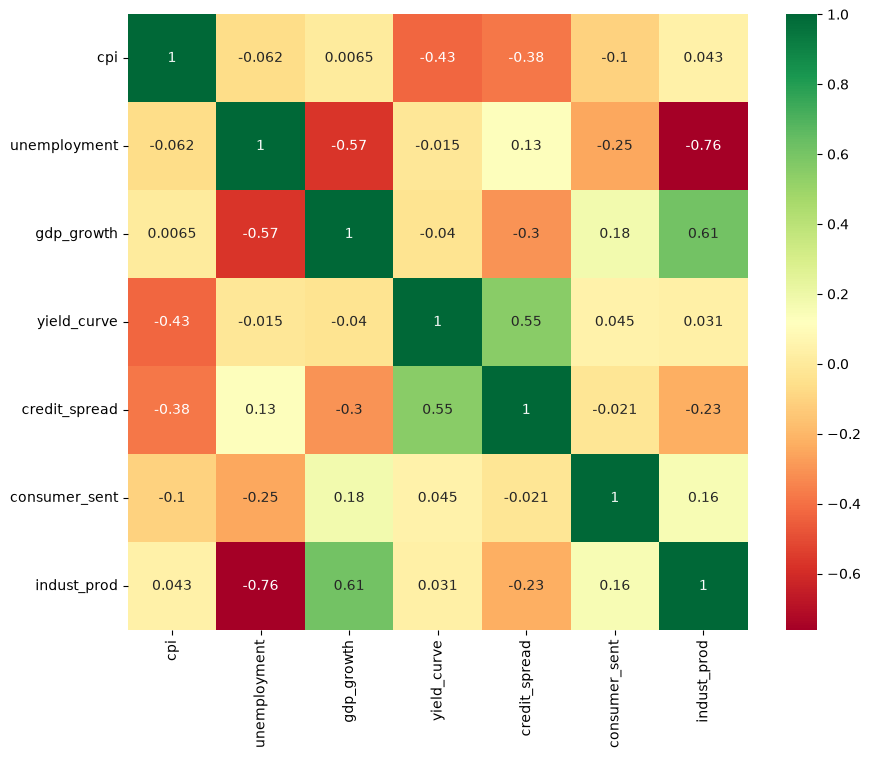

In [170]:
import seaborn as sns

corr_matrix = aligned_df.corr()
print(corr_matrix)

hmap = plt.figure(figsize = (10, 8))
sns.heatmap(corr_matrix, annot = True, cmap = 'RdYlGn')
plt.savefig(os.path.join(project_root, 'outputs', 'macro_features_heatmap.png'))

    

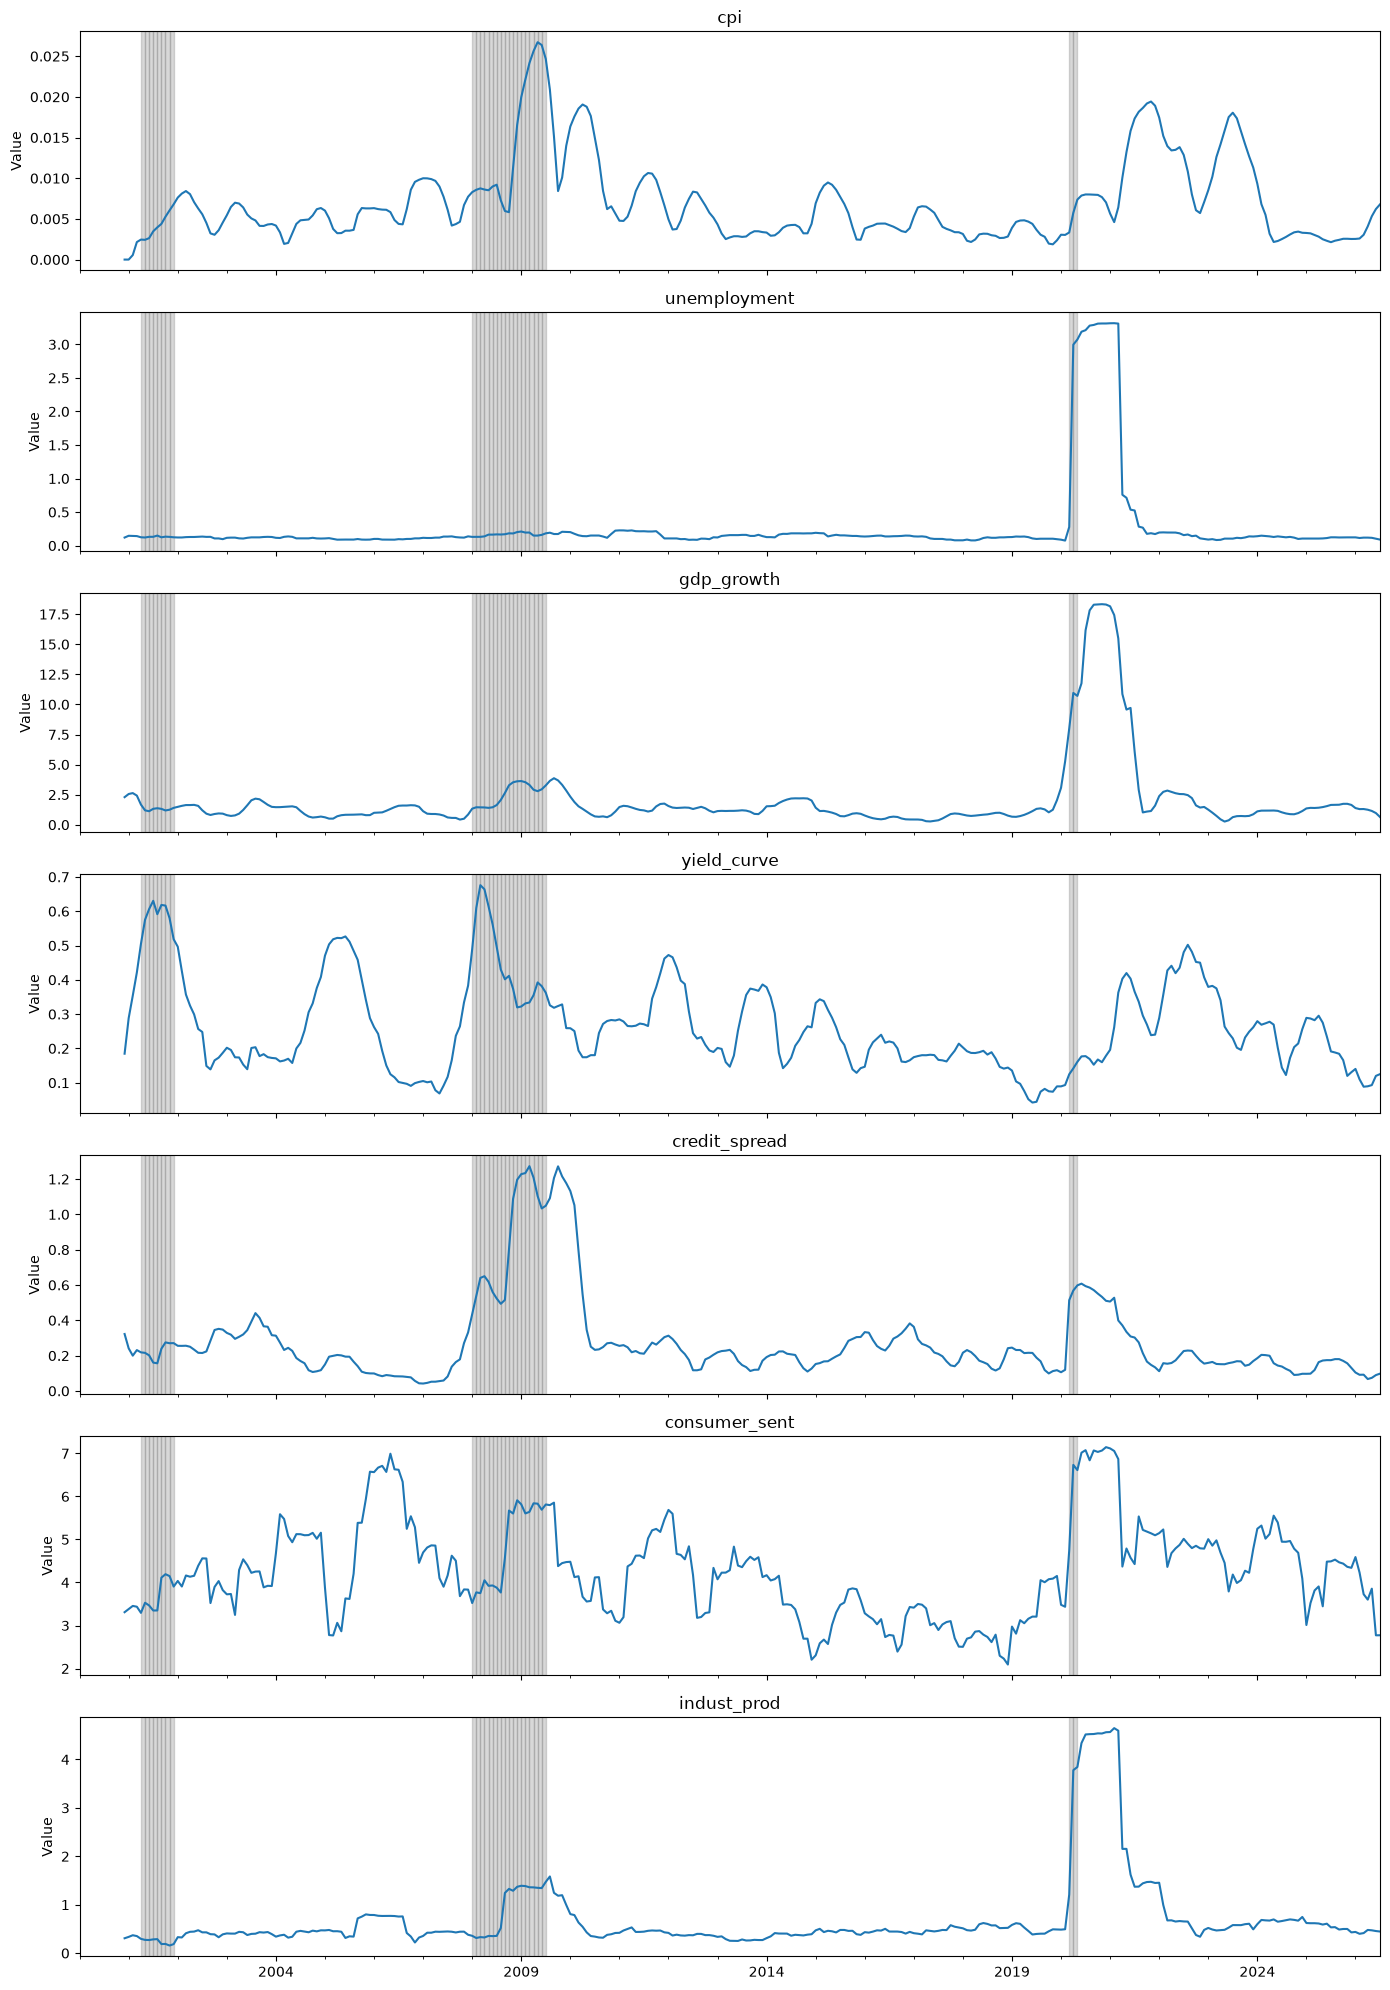

In [171]:
rolling_val = aligned_df.rolling(12).std()

fig, axes = plt.subplots(7, 1, figsize = (14, 20), sharex = True)
for i, col in enumerate(rolling_val.columns):
    ax = axes[i]
    rolling_val[col].plot(ax = ax)
    ax.set_title(col)
    ax.set_ylabel("Value")

    for date, value in recession.items():
        if value == 1:
            ax.axvspan(date, date + pd.offsets.MonthEnd(1), color = 'grey', alpha = 0.3)

plt.tight_layout()
plt.savefig(os.path.join(project_root, 'outputs', 'rolling_volatility.png'))
plt.show()